# 🔬 LLM4Teach — Research Ablation Framework

Works **locally (Windows/Linux/Mac)** and on **Kaggle** (offline mode auto-enabled).

| Phase | Name | What's On |
|-------|------|-----------|
| 1 | `ppo_only` | Pure PPO — no teacher, no kickstarting |
| 2 | `planner` | PPO + LLM teacher + kickstarting |
| 3 | `reflection` | Phase 2 + episode reflections + memory |

**Edit Cell 3 only.**

In [1]:
# ── Cell 1: Environment detection + installs ──────────────────────────
import os, sys, subprocess,pandas as pd

# ── Detect runtime environment ────────────────────────────────────────
IS_KAGGLE = (
    os.path.exists('/kaggle/working')
    or 'KAGGLE_KERNEL_RUN_TYPE' in os.environ
    or os.path.exists('/kaggle')
)
IS_COLAB  = 'google.colab' in sys.modules or os.path.exists('/content')
ENV_NAME  = 'Kaggle' if IS_KAGGLE else ('Colab' if IS_COLAB else 'Local')
print(f'Runtime: {ENV_NAME}')

# ── Install packages ─────────────────────────────────────────────────
PACKAGES = [
    'minigrid==3.1.0',
    'gymnasium==1.3.0',
    'opencv-python-headless',  # headless — no display needed
    'matplotlib',
    'tensorboard',
    'ipywidgets',
]
if IS_KAGGLE or IS_COLAB:
    print('Installing packages...')
    subprocess.run([sys.executable, '-m', 'pip', 'install'] + PACKAGES + ['--quiet'], check=False)
    print('Packages installed.')
else:
    # Local: just check they're importable, don't force reinstall every run
    missing = []
    for pkg in ['minigrid', 'gymnasium', 'torch', 'cv2']:
        try: __import__(pkg)
        except ImportError: missing.append(pkg)
    if missing:
        print(f'Installing missing: {missing}')
        subprocess.run([sys.executable, '-m', 'pip', 'install'] + PACKAGES + ['--quiet'], check=False)

print('✅ Environment ready')

Runtime: Kaggle
Installing packages...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.1/140.1 kB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 953.9/953.9 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 59.9 MB/s eta 0:00:00
Packages installed.
✅ Environment ready


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
kaggle-environments 1.29.3 requires gymnasium==1.2.0, but you have gymnasium 1.3.0 which is incompatible.
dopamine-rl 4.1.2 requires gym<=0.25.2, but you have gym 0.26.2 which is incompatible.


In [2]:
# ── Cell 2: Repo path detection + imports ─────────────────────────────
import sys, os, warnings, time, json, csv
warnings.filterwarnings('ignore')

# ── Locate the project root automatically ────────────────────────────
def _find_repo():
    # 1. Already set by user
    if 'REPO' in globals() and os.path.isdir(globals()['REPO']):
        return globals()['REPO']
    # 2. Kaggle: dataset added as input
    for kaggle_candidate in [
        '/kaggle/working/LLM4Teach-main',
        '/kaggle/input/llm4teach/LLM4Teach-main',
        '/kaggle/input/llm4teach-main/LLM4Teach-main',
        '/kaggle/working',
    ]:
        if os.path.exists(os.path.join(kaggle_candidate, 'Game.py')):
            return kaggle_candidate
    # 3. This notebook's own directory
    nb_dir = os.path.abspath(os.path.dirname(globals().get('__vsc_ipynb_file__', '__file__')))
    if os.path.exists(os.path.join(nb_dir, 'Game.py')):
        return nb_dir
    # 4. Current working directory
    cwd = os.getcwd()
    if os.path.exists(os.path.join(cwd, 'Game.py')):
        return cwd
    # 5. Walk up from CWD
    p = cwd
    for _ in range(5):
        if os.path.exists(os.path.join(p, 'Game.py')):
            return p
        p = os.path.dirname(p)
    raise FileNotFoundError(
        'Cannot find LLM4Teach repo (Game.py not found).\n'
        'Set REPO manually in Cell 2, e.g.:  REPO = "/kaggle/working/LLM4Teach"'
    )

# ── MANUAL OVERRIDE: set REPO here if auto-detection fails ──────────
# REPO = '/kaggle/input/llm4teach/LLM4Teach-main'     # ← Kaggle
# REPO = r'C:\Users\HP\Downloads\LLM4Teach-main (1)\LLM4Teach-main'  # ← Windows local

REPO = "/kaggle/input/datasets/parthjade/zips40/LLM4Teach-main --- improving later in memory ,ks"

# Kaggle /kaggle/input is READ-ONLY → copy project to writable /kaggle/working
if IS_KAGGLE and REPO.startswith('/kaggle/input'):
    import shutil
    _dst = '/kaggle/working/LLM4Teach'
    if not os.path.exists(_dst):
        print(f'Copying project to writable dir: {_dst}')
        shutil.copytree(REPO, _dst)
    REPO = _dst

print(f'Project root: {REPO}')

if REPO not in sys.path:
    sys.path.insert(0, REPO)
os.chdir(REPO)


# Writable output dir (important on Kaggle where input datasets are read-only)
if IS_KAGGLE:
    OUTPUT_DIR = '/kaggle/working'
    os.makedirs(f'{OUTPUT_DIR}/results', exist_ok=True)
    os.makedirs(f'{OUTPUT_DIR}/checkpoints', exist_ok=True)
    # Symlink results → /kaggle/working/results so all code writes there
    for _d in ['results', 'checkpoints', 'log']:
        _src = os.path.join(REPO, _d)
        _dst = os.path.join(OUTPUT_DIR, _d)
        os.makedirs(_dst, exist_ok=True)
        if not os.path.exists(_src):
            try: os.symlink(_dst, _src)
            except Exception: pass
else:
    OUTPUT_DIR = REPO

print(f'Output dir  : {OUTPUT_DIR}')
print(f'Is Kaggle   : {IS_KAGGLE}')

# ── Force-reload project modules (safe for re-runs) ──────────────────
for _m in list(sys.modules.keys()):
    if any(x in _m for x in ['Game','algos','skill','env','mediator',
                               'teacher','planner','utils','experiment',
                               'memory','viz']):
        del sys.modules[_m]

import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from IPython.display import clear_output, display, Image as IPImage
from types import SimpleNamespace

# ── Workaround: PyTorch 2.10 + Python 3.12 torch._dynamo import crash ─────────
# torch.optim.Adam lazily imports torch._dynamo, which hits an AssertionError
# deep in triton_kernel_wrap.py on this Kaggle environment. LLM4Teach never
# uses torch.compile, so we stub _dynamo with a minimal no-op that satisfies
# the torch._compile.inner() call that guards every optimizer.
try:
    import torch._dynamo as _td
    _td.config.suppress_errors = True   # already importable — just suppress errors
except (AssertionError, Exception) as _dyn_err:
    import types as _types
    _stub = _types.ModuleType('torch._dynamo')
    _stub.is_compiling = lambda: False
    _stub.disable      = lambda f=None, **kw: (lambda fn: fn) if f is None else f
    _stub.config       = _types.SimpleNamespace(suppress_errors=True)
    sys.modules['torch._dynamo'] = _stub
    print(f'[fix] torch._dynamo stubbed ({type(_dyn_err).__name__}) — '
          f'torch.compile disabled, optimizers work normally.')

from experiment_config import ExperimentConfig, build_experiment_config, PHASE_ORDER
from experiment_runner  import (
    build_game, run_phase, evaluate_phase,
    save_results, save_eval_results,
    aggregate_results, run_research_pipeline,
)
from utils.qwen_llm import QwenLLM

print(f'Python   : {sys.version.split()[0]}')
print(f'PyTorch  : {torch.__version__}')
print(f'Device   : {"CUDA (" + torch.cuda.get_device_name(0) + ")" if torch.cuda.is_available() else "CPU"}')
import gymnasium; print(f'Gym      : {gymnasium.__version__}')
import minigrid;  print(f'MiniGrid : {minigrid.__version__}')
print('\n✅ All imports OK')

Copying project to writable dir: /kaggle/working/LLM4Teach
Project root: /kaggle/working/LLM4Teach
Output dir  : /kaggle/working
Is Kaggle   : True
Python   : 3.12.13
PyTorch  : 2.10.0+cu128
Device   : CUDA (Tesla T4)
Gym      : 1.3.0
MiniGrid : 3.1.0

✅ All imports OK


In [ ]:
# ╔═══════════════════════════════════════════════════════════════════╗
# ║       ⚙️  MASTER CONFIGURATION — EDIT THIS CELL ONLY          
# ╚═══════════════════════════════════════════════════════════════════╝
#cell3

# ── Task + hardware ──────────────────────────────────────────────────
# TASK options:
#   'simpledoorkey'  — basic key-door navigation (Min5-Max10 room, no colour, no lava)
#   'lavadoorkey'    — key-door with lethal lava tiles; charts show lava collision rate
#   'coloreddoorkey' — multiple keys; must match door colour; charts show wrong-key rate
#simpledoorkey
TASK   = 'simpledoorkey'
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
SEED   = 42

# ── Single experiment OR full pipeline ───────────────────────────────
EXPERIMENT            = 'reflection' # 'ppo_only'|'planner'|'reflection'
RUN_RESEARCH_PIPELINE = False     # True → run the 3-phase pipeline (ppo_only, planner, reflection)

# ── LLM backend ──────────────────────────────────────────────────────
#
#  'offline' : Pre-computed plans — works everywhere (Kaggle, CPU, no internet).
#  'ollama'  : Local Qwen via Ollama — works locally AND on Kaggle *if* an
#              Ollama server is reachable in the kernel (start it in a cell:
#              !curl -fsSL https://ollama.com/install.sh | sh; ollama serve &;
#              ollama pull qwen2.5:3b). If Ollama is NOT reachable the notebook
#              AUTOMATICALLY FALLS BACK to offline (verified in Cell 4).
#
#  DashScope is intentionally not used.

QWEN_BACKEND = 'ollama'          # 'offline' | 'ollama'  (auto-falls back to offline)
QWEN_MODEL   = 'qwen2.5:3b'      # Ollama planner model

# Ollama is now ATTEMPTED on Kaggle too (it used to work via an in-kernel server).
# Reachability is checked in Cell 4; offline is the automatic backup.

# ── Per-phase training schedules ─────────────────────────────────────
PHASE_CONFIGS = {
    'ppo_only': {
        'total_iterations': 200,
        'ppo_epochs': 5,
        'batch_size': 128,
        'episodes_per_iteration': 10
    },
    'planner': {
        'total_iterations': 200,
        'ppo_epochs': 5,
        'batch_size': 128,
        'episodes_per_iteration': 10
    },
    'reflection': {
        'total_iterations': 2000,
        'ppo_epochs': 5,
        'batch_size': 128,
        'episodes_per_iteration': 10
    }
}

# ── Global overrides ─────────────────────────────────────────────────
# Quick test: set N_ITR_OVERRIDE=50 to verify the pipeline runs end-to-end
N_ITR_OVERRIDE      = None    # set e.g. 100 for a smoke-test
PPO_EPOCHS_OVERRIDE = None
BATCH_SIZE_OVERRIDE = None
LEARNING_RATE       = 3e-4
ENTROPY_COEF        = 0.05

# ── Evaluation ───────────────────────────────────────────────────────
EVAL_INTERVAL = 50
NUM_EVAL      = 10
EVAL_EPISODES = 20

# ── Plotting ─────────────────────────────────────────────────────────
PLOT_EVERY = 50
SAVE_PLOTS = True

# Apply global overrides
for _pname in PHASE_CONFIGS:
    if N_ITR_OVERRIDE      is not None: PHASE_CONFIGS[_pname]['total_iterations']    = N_ITR_OVERRIDE
    if PPO_EPOCHS_OVERRIDE  is not None: PHASE_CONFIGS[_pname]['ppo_epochs']          = PPO_EPOCHS_OVERRIDE
    if BATCH_SIZE_OVERRIDE  is not None: PHASE_CONFIGS[_pname]['batch_size']          = BATCH_SIZE_OVERRIDE
    PHASE_CONFIGS[_pname]['learning_rate'] = LEARNING_RATE
    PHASE_CONFIGS[_pname]['entropy_coef']  = ENTROPY_COEF
    PHASE_CONFIGS[_pname]['eval_interval'] = EVAL_INTERVAL
    PHASE_CONFIGS[_pname]['num_eval']      = NUM_EVAL

print(f'Task           : {TASK}')
print(f'Device         : {DEVICE}')
print(f'Runtime        : {ENV_NAME}')
print(f'Experiment     : {EXPERIMENT}')
print(f'Pipeline mode  : {RUN_RESEARCH_PIPELINE}')
print(f'LLM backend    : {QWEN_BACKEND}')
print()
print('PHASE_CONFIGS:')
for _pn, _pc in PHASE_CONFIGS.items():
    print(f'  {_pn:<12} itr={_pc["total_iterations"]:<6} epochs={_pc["ppo_epochs"]:<3} '
          f'batch={_pc["batch_size"]:<4} lr={_pc["learning_rate"]}')

In [4]:
# ── Cell 4: LLM backend — bootstrap Ollama (Kaggle/Colab) + connect, offline fallback ─
# Why this cell exists: on Kaggle there is NO Ollama server by default, so a plain
# reachability check always failed ("llm not ready"). This cell INSTALLS Ollama,
# STARTS the server, and PULLS the model in-kernel (needs Internet: ON), then
# connects. If anything fails it falls back to OFFLINE. Mode is printed + logged.
import os, subprocess, time
_qwen_llm = None

def _record_llm_mode(line):
    """Print the active LLM mode AND append it to results/llm_mode.log."""
    print(line)
    try:
        _logp = os.path.join(OUTPUT_DIR, 'results', 'llm_mode.log')
        os.makedirs(os.path.dirname(_logp), exist_ok=True)
        with open(_logp, 'a', encoding='utf-8') as _f:
            print(line, file=_f)
    except Exception:
        pass

def _ollama_up(timeout=2):
    try:
        import requests as _rq
        return _rq.get('http://localhost:11434/api/tags', timeout=timeout).status_code == 200
    except Exception:
        return False

def _start_ollama_server(wait=30):
    subprocess.Popen(['ollama', 'serve'],
                     stdout=open('/tmp/ollama.log', 'w'), stderr=subprocess.STDOUT)
    for i in range(wait):
        if _ollama_up():
            print(f'   Ollama server ready (took {i+1}s)')
            return True
        time.sleep(1)
    print('   Ollama server did not come up in time. Last log:')
    try:
        print(open('/tmp/ollama.log').read()[-400:])
    except Exception:
        pass
    return False

def _install_ollama():
    print('Installing Ollama (zstd + install.sh) — needs Internet: ON ...')
    subprocess.run('apt-get install -y zstd', shell=True,
                   stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
    subprocess.run('curl -fsSL https://ollama.ai/install.sh | sh', shell=True,
                   stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
    return subprocess.run('which ollama', shell=True, capture_output=True).returncode == 0

def _ensure_model(model):
    """Pull the model if not already present. Returns True if available."""
    import requests as _rq
    base = model.split(':')[0]
    try:
        models = [m['name'] for m in _rq.get('http://localhost:11434/api/tags', timeout=4).json().get('models', [])]
    except Exception:
        models = []
    if not any(base in n for n in models):
        print(f'Pulling {model} (first time ~2-5 min) ...')
        os.system(f'ollama pull {model}')
        try:
            models = [m['name'] for m in _rq.get('http://localhost:11434/api/tags', timeout=4).json().get('models', [])]
        except Exception:
            models = []
    return any(base in n for n in models)

if QWEN_BACKEND == 'offline':
    _record_llm_mode('LLM backend: OFFLINE - planner uses pre-computed plans (no LLM calls).')

elif QWEN_BACKEND == 'ollama':
    print(f'Preparing Ollama (IS_KAGGLE={IS_KAGGLE}, IS_COLAB={IS_COLAB}) ...')
    # 1) Make sure a server is running — install/start it on Kaggle/Colab.
    if not _ollama_up():
        if IS_KAGGLE or IS_COLAB:
            _has = subprocess.run('which ollama', shell=True, capture_output=True).returncode == 0
            if not _has:
                _has = _install_ollama()
            if _has:
                _start_ollama_server()
        else:
            print('   Ollama not running locally. Start it first:  ollama serve')

    # 2) Connect if reachable + model present (pull if missing).
    try:
        if not _ollama_up():
            raise ConnectionError('Ollama server not reachable')
        if not _ensure_model(QWEN_MODEL):
            raise RuntimeError(f'model "{QWEN_MODEL}" unavailable after pull')
        _qwen_llm = QwenLLM(backend='ollama', model=QWEN_MODEL)
        _resp = _qwen_llm.call(system_prompt='Reply with one word.', user_prompt='Say: explore')
        _record_llm_mode(f'LLM backend: ONLINE (Ollama)  model={QWEN_MODEL}  test="{_resp[:40]}"')
    except Exception as _e:
        _record_llm_mode(f'Ollama unavailable ({_e}) -> FALLBACK to OFFLINE.')
        _qwen_llm    = None
        QWEN_BACKEND = 'offline'

else:
    _record_llm_mode(f'Unknown backend "{QWEN_BACKEND}" -> OFFLINE.')
    QWEN_BACKEND = 'offline'

_record_llm_mode(f'=> Active LLM backend: {QWEN_BACKEND.upper()}  |  live LLM ready: {_qwen_llm is not None}')


Preparing Ollama (IS_KAGGLE=True, IS_COLAB=True) ...
Installing Ollama (zstd + install.sh) — needs Internet: ON ...
   Ollama server ready (took 4s)
Pulling qwen2.5:3b (first time ~2-5 min) ...


pulling manifest ⠋ pulling manifest ⠙ pulling manifest ⠹ pulling manifest ⠸ pulling manifest ⠼ pulling manifest ⠴ pulling manifest ⠦ pulling manifest ⠧ pulling manifest ⠇ pulling manifest ⠏ pulling manifest ⠋ pulling manifest ⠙ pulling manifest ⠹ pulling manifest ⠸ pulling manifest ⠼ pulling manifest ⠴ pulling manifest ⠦ pulling manifest 
pulling 5ee4f07cdb9b:   2% ▕                  ▏  30 MB/1.9 GB                  pulling manifest 
pulling 5ee4f07cdb9b:   4% ▕                  ▏  71 MB/1.9 GB                  pulling manifest 
pulling 5ee4f07cdb9b:   9% ▕█                 ▏ 167 MB/1.9 GB                  pulling manifest 
pulling 5ee4f07cdb9b:  14% ▕██                ▏ 264 MB/1.9 GB                  pulling manifest 
pulling 5ee4f07cdb9b:  16% ▕██                ▏ 312 MB/1.9 GB                  pulling manifest 
pulling 5ee4f07cdb9b:  21% ▕███               ▏ 413 MB/1.9 GB                  pulling manifest 
pulling 5ee4f07cdb9b:  26% ▕████              ▏ 499 MB/1.9 GB                

[Qwen] Connected successfully — model 'qwen2.5:3b' found.
LLM backend: ONLINE (Ollama)  model=qwen2.5:3b  test="Exploring is a great way to discover new"
=> Active LLM backend: OLLAMA  |  live LLM ready: True


In [5]:
# ── Cell 5: MiniGrid episode renderer (inline frame display) ──────────
# Run a single evaluation episode and display the rendered frames inline.
# Works on Kaggle, Colab, and local Jupyter — no display server required.

def render_episode_inline(
    cfg=None, task=None, max_steps=150, fps=8, n_episodes=1,
    use_teacher=False, figsize=(5, 5),
):
    """
    Run one episode and display each frame inline (no external window needed).
    Captures frames via env.render() → base64 PNG → IPython Image.

    Parameters
    ----------
    cfg        : ExperimentConfig — uses EXPERIMENT config if None
    task       : task name — uses TASK if None
    max_steps  : max steps per episode
    fps        : display speed (frames per second, capped at 15)
    n_episodes : how many episodes to render
    use_teacher: use teacher policy (symbolic planner) instead of PPO
    figsize    : matplotlib figure size
    """
    import cv2, base64, time
    import torch
    from IPython.display import display, Image as IPImage, clear_output
    import matplotlib.pyplot as plt
    import io

    _task = task or TASK
    _cfg  = cfg  or build_experiment_config(EXPERIMENT, phase_configs=PHASE_CONFIGS)
    _device = 'cuda' if torch.cuda.is_available() else 'cpu'

    print(f'Building game for rendering: {_task} / {_cfg.name}')
    game = build_game(_cfg, task=_task, device=_device, seed=SEED,
                      qwen_llm=_qwen_llm if _cfg.use_planner and _qwen_llm else None)

    _delay = max(1.0 / min(fps, 15), 0.0)

    for ep in range(n_episodes):
        with torch.no_grad():
            obs  = game.env.reset()
            done = False
            step = 0
            ep_reward = 0.0
            game.teacher_policy.reset()
            mask   = torch.FloatTensor([1]).to('cpu')
            states = game.student_policy.model.init_states('cpu') if game.recurrent else None

            while not done and step < max_steps:
                # Get action
                if use_teacher:
                    teacher_p = game.teacher_policy(obs[0])
                    action_id = int(np.argmax(teacher_p))
                else:
                    dist, _, states = game.student_policy(
                        torch.Tensor(obs).to('cpu'), mask, states)
                    action_id = int(dist.sample().cpu())

                # Step environment
                next_obs, reward, done_arr, info = game.env.step(np.array([action_id]))
                step_r = float(reward.squeeze())
                ep_reward += step_r
                done = bool(done_arr.squeeze())

                # Render frame
                frame_rgb = game.env.render()
                if frame_rgb is not None:
                    # Add annotation overlay
                    from Game import _annotate_frame, _ACTION_NAMES
                    frame_ann = _annotate_frame(
                        frame_rgb, step, action_id, ep_reward,
                        plan='teacher' if use_teacher else 'ppo',
                        success=(ep_reward > 0 and done) or None
                    )
                    # Display via matplotlib (works everywhere)
                    fig, ax = plt.subplots(1, 1, figsize=figsize)
                    ax.imshow(frame_ann)
                    ax.axis('off')
                    title = (f'Episode {ep+1}/{n_episodes}  '
                             f'Step {step}  Reward {ep_reward:.2f}')
                    if done:
                        outcome = '✅ SUCCESS' if ep_reward > 0 else '❌ FAILED'
                        title = f'{outcome} — {title}'
                    ax.set_title(title, fontsize=10)
                    plt.tight_layout(pad=0.2)
                    clear_output(wait=True)
                    plt.show()
                    if _delay > 0:
                        time.sleep(_delay)
                    else:
                        plt.close(fig)

                obs   = next_obs
                step += 1

        outcome = '✅ SUCCESS' if ep_reward > 0 else '❌ FAILED'
        print(f'Episode {ep+1}: {outcome}  steps={step}  reward={ep_reward:.3f}')

# Quick preview: render 1 episode with teacher policy (offline planner)
print('Preview: rendering 1 teacher episode (offline planner)...')
print('(Change use_teacher=False to watch PPO, n_episodes=3 for more)')
_prev_cfg = build_experiment_config('full', phase_configs=PHASE_CONFIGS)
render_episode_inline(_prev_cfg, max_steps=300, fps=10, use_teacher=True)

Preview: rendering 1 teacher episode (offline planner)...
(Change use_teacher=False to watch PPO, n_episodes=3 for more)
Building game for rendering: simpledoorkey_large / full
[Runner] Phase 'full': ONLINE planning — QwenLLM
[INFO]: resetting the task: simpledoorkey_large


2026-06-14 19:08:21.839640: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1781464102.014342      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1781464102.067882      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1781464102.486174      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781464102.486214      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1781464102.486217      23 computation_placer.cc:177] computation placer alr

Logging to log/ppo/simpledoorkey_large/checkpoints/phase5_full
use MLP......
[Game] TrajectoryLogger active → log/ppo/simpledoorkey_large/checkpoints/phase5_full/trajectory/
[Runner] Online LLM wired into planner.
[QwenReflector] Ollama ✅  model 'qwen2.5:3b' found.
[Game] Reflection memory wired into planner.
[Runner] Reflection system wired (reflector backend=ollama, model=qwen2.5:3b).
[LLM-MODE] phase='full' | planner=ONLINE (Ollama LLM) | reflector=ollama
new obs: Agent sees <nothing>, holds <nothing>.
[Qwen] Raw response: explore
[Qwen] Inference succeeded — plan: explore
Agent sees <nothing>, holds <nothing>.:(['explore'], [1.0])
[TeacherPolicy] Intervention #1 — reason: failed_interaction | obs: 'Agent sees <nothing>, holds <nothing>.'
[TeacherPolicy] Intervention #2 — reason: stuck | obs: 'Agent sees <nothing>, holds <nothing>.'
[TeacherPolicy] Intervention #3 — reason: stuck | obs: 'Agent sees <nothing>, holds <nothing>.'
[TeacherPolicy] Intervention #4 — reason: stuck | obs: '

In [6]:
import os
for root, dirs, files in os.walk("/kaggle/working"):
    for f in files:
        if f in ("__init__.py", "task_info.json", "planner.py", "Game.py"):
            print(os.path.join(root, f))

/kaggle/working/LLM4Teach/planner.py
/kaggle/working/LLM4Teach/Game.py
/kaggle/working/LLM4Teach/memory/__init__.py
/kaggle/working/LLM4Teach/algos/__init__.py
/kaggle/working/LLM4Teach/viz/__init__.py
/kaggle/working/LLM4Teach/prompt/task_info.json
/kaggle/working/LLM4Teach/simulator/__init__.py
/kaggle/working/LLM4Teach/env/__init__.py
/kaggle/working/LLM4Teach/skill/__init__.py
/kaggle/working/LLM4Teach/utils/__init__.py


In [7]:
# ── Cell 6: Visualization helpers ─────────────────────────────────────
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D

os.makedirs(os.path.join(OUTPUT_DIR, 'results', 'plots'), exist_ok=True)

PHASE_COLORS = {
    'ppo_only':   '#e74c3c',
    'planner':    '#e67e22',
    'reflection': '#2ecc71',
    'replanning': '#3498db',
    'full':       '#9b59b6',
}
PHASE_LABELS = {
    'ppo_only':   'Phase 1: PPO Only',
    'planner':    'Phase 2: + Planner',
    'reflection': 'Phase 3: + Reflection',
    'replanning': 'Phase 4: + Replanning',
    'full':       'Phase 5: Full System',
}

def _smooth(x, w=20):
    w = min(w, max(len(x), 1))
    if w < 2: return np.array(x), 0
    return np.convolve(x, np.ones(w)/w, mode='valid'), w - 1


# ── Env-aware episode colour ──────────────────────────────────────────────────
def _ep_color(row, task):
    t = str(task).lower()
    if int(row.get('success', 0)):
        return '#2ecc71'   # green  — success
    if t == 'lavadoorkey' and int(row.get('lava_collision', 0)):
        return '#e74c3c'   # red    — lava death
    if t == 'coloreddoorkey' and int(row.get('wrong_key_for_door', 0)):
        return '#e67e22'   # orange — wrong key colour
    return '#e74c3c'       # red    — other failure


# ── Find metrics.csv for a phase across possible write locations ──────────────
def _find_metrics_csv(phase, task=None):
    import glob as _gl
    _task = task or TASK
    candidates = [
        os.path.join(OUTPUT_DIR, 'results', phase, 'episodes.csv'),
        os.path.join(OUTPUT_DIR, 'results', phase, 'metrics.csv'),
    ]
    for pattern in [
        os.path.join(REPO, 'log', 'ppo', _task, 'checkpoints',
                     f'*_{phase}', 'trajectory', 'metrics.csv'),
        os.path.join(REPO, 'log', 'ppo', _task, 'checkpoints',
                     f'*_{phase}', 'metrics.csv'),
    ]:
        candidates += sorted(_gl.glob(pattern))
    return next((c for c in candidates if os.path.exists(c)), None)


# ── Episode length scatter — green = success, red = failure / lava ───────────
def plot_episode_length_colored(csv_path, phase, task=None, save=True,
                                window=30, title_suffix=''):
    _task = str(task or TASK).lower()
    if not os.path.exists(csv_path):
        print(f'[plot_ep_length] CSV not found: {csv_path}'); return None
    df = pd.read_csv(csv_path)
    if df.empty or 'steps' not in df.columns:
        print('[plot_ep_length] No step data'); return None

    fig, ax = plt.subplots(figsize=(14, 5))
    clrs = [_ep_color(row, _task) for _, row in df.iterrows()]
    ax.scatter(df.index, df['steps'], c=clrs, alpha=0.45, s=12, linewidths=0)

    # Smoothed mean overlay
    sm, off = _smooth(df['steps'].values, window)
    ax.plot(range(off, len(df)), sm, color='#2c3e50', lw=2.2, zorder=5,
            label=f'Smoothed mean (w={window})')

    # Legend
    legend_elems = [mpatches.Patch(color='#2ecc71', label='Success')]
    if _task == 'lavadoorkey':
        legend_elems += [mpatches.Patch(color='#e74c3c', label='Failure / Lava death')]
    elif _task == 'coloreddoorkey':
        legend_elems += [
            mpatches.Patch(color='#e67e22', label='Wrong key colour'),
            mpatches.Patch(color='#e74c3c', label='Other failure'),
        ]
    else:
        legend_elems += [mpatches.Patch(color='#e74c3c', label='Failure')]
    legend_elems.append(
        Line2D([0], [0], color='#2c3e50', lw=2, label=f'Smoothed mean (w={window})'))
    ax.legend(handles=legend_elems, fontsize=9, loc='upper right')

    _lbl  = PHASE_LABELS.get(phase, phase)
    _succ = df['success'].mean() if 'success' in df.columns else float('nan')
    ax.set_title(
        f'Episode Length — {_lbl} | {task or TASK}  '
        f'({len(df)} eps, success={_succ:.1%})'
        + (f'  {title_suffix}' if title_suffix else ''),
        fontsize=12, fontweight='bold')
    ax.set_xlabel('Episode'); ax.set_ylabel('Steps'); ax.grid(alpha=0.25)
    plt.tight_layout()

    if save:
        fp = os.path.join(OUTPUT_DIR, 'results', 'plots',
                          f'ep_length_{phase}_{task or TASK}.png')
        os.makedirs(os.path.dirname(fp), exist_ok=True)
        fig.savefig(fp, dpi=110, bbox_inches='tight')
        print(f'Saved: {fp}')
    plt.show(); plt.close(fig)
    return fig


# ── Env-specific failure metrics (2 or 3 panels depending on env) ─────────────
def plot_env_specific_charts(csv_path, phase, task=None, save=True, window=30):
    import pandas as pd
    _task = str(task or TASK).lower()
    if not os.path.exists(csv_path): return None
    df = pd.read_csv(csv_path)
    if df.empty: return None

    _env_label = {'lavadoorkey': 'LavaDoorKey',
                  'coloreddoorkey': 'ColoredDoorKey'}.get(_task, 'SimpleDoorKey')
    _n_cols = 3 if _task in ('lavadoorkey', 'coloreddoorkey') else 2
    fig, axes = plt.subplots(1, _n_cols, figsize=(6 * _n_cols, 4))
    if _n_cols == 2:
        axes = list(axes)

    # Panel 1: success rate (all envs)
    ax = axes[0]
    if 'success' in df.columns:
        sm, off = _smooth(df['success'].astype(float).values, window)
        ax.plot(range(off, len(df)), sm, '#2ecc71', lw=2)
        ax.fill_between(range(off, len(df)), 0, sm, color='#2ecc71', alpha=0.12)
        mean_sr = df['success'].mean()
        ax.axhline(mean_sr, color='#27ae60', ls='--', lw=1, alpha=0.7)
        ax.text(len(df) * 0.02, mean_sr + 0.03, f'mean={mean_sr:.2f}', fontsize=8)
    ax.set_ylim(-0.05, 1.05)
    ax.set_title('Success Rate (smoothed)'); ax.set_xlabel('Episode'); ax.grid(alpha=0.25)

    # Panel 2: env-specific rate
    ax = axes[1]
    if _task == 'lavadoorkey' and 'lava_collision' in df.columns:
        sm2, off2 = _smooth(df['lava_collision'].astype(float).values, window)
        ax.plot(range(off2, len(df)), sm2, '#e74c3c', lw=2)
        ax.fill_between(range(off2, len(df)), 0, sm2, color='#e74c3c', alpha=0.12)
        if df['lava_collision'].sum() > 0:
            ax.axhline(df['lava_collision'].mean(), color='#c0392b', ls='--', lw=1, alpha=0.7)
        ax.set_title('Lava Collision Rate (smoothed)')
    elif _task == 'coloreddoorkey' and 'wrong_key_for_door' in df.columns:
        sm2, off2 = _smooth(df['wrong_key_for_door'].astype(float).values, window)
        ax.plot(range(off2, len(df)), sm2, '#e67e22', lw=2)
        ax.fill_between(range(off2, len(df)), 0, sm2, color='#e67e22', alpha=0.12)
        if df['wrong_key_for_door'].sum() > 0:
            ax.axhline(df['wrong_key_for_door'].mean(), color='#d35400', ls='--', lw=1, alpha=0.7)
        ax.set_title('Wrong Key Colour Rate (smoothed)')
    else:
        ax.set_title('Failure Count')
        if 'success' in df.columns:
            fail_count = int((df['success'] == 0).sum())
            ax.bar(['success', 'failure'], [len(df) - fail_count, fail_count],
                   color=['#2ecc71', '#e74c3c'])
    ax.set_xlabel('Episode'); ax.grid(alpha=0.25)

    # Panel 3 (lava / coloured only): failure type breakdown
    if _n_cols == 3:
        ax = axes[2]
        if 'failure_type' in df.columns:
            fails = df[df['success'] == 0] if 'success' in df.columns else df
            if len(fails) > 0:
                counts = fails['failure_type'].value_counts().head(5)
                bar_clrs = ['#e74c3c', '#e67e22', '#3498db', '#95a5a6', '#9b59b6']
                bars = ax.bar(range(len(counts)), counts.values,
                              color=bar_clrs[:len(counts)])
                ax.set_xticks(range(len(counts)))
                ax.set_xticklabels(counts.index, rotation=25, ha='right', fontsize=8)
                for b, v in zip(bars, counts.values):
                    ax.text(b.get_x() + b.get_width() / 2, v + 0.3,
                            str(v), ha='center', fontsize=8)
        ax.set_title('Failure Type Breakdown'); ax.grid(alpha=0.25, axis='y')

    plt.suptitle(
        f'{_env_label} — {PHASE_LABELS.get(phase, phase)} | {len(df)} episodes',
        fontsize=12, fontweight='bold')
    plt.tight_layout()

    if save:
        fp = os.path.join(OUTPUT_DIR, 'results', 'plots',
                          f'env_metrics_{phase}_{task or TASK}.png')
        os.makedirs(os.path.dirname(fp), exist_ok=True)
        fig.savefig(fp, dpi=110, bbox_inches='tight')
        print(f'Saved: {fp}')
    plt.show(); plt.close(fig)
    return fig


# ── Full final chart set for one phase — reads metrics.csv directly ───────────
def plot_final_charts_from_csv(phase, task=None, save=True):
    import pandas as pd
    _task = task or TASK
    csv   = _find_metrics_csv(phase, _task)
    if not csv:
        print(f'[final_charts] No metrics.csv for phase={phase}, task={_task}'); return
    df = pd.read_csv(csv)
    print(f'\n{"="*55}')
    print(f'  FINAL CHARTS  phase={phase}  task={_task}')
    print(f'  Source : {csv}')
    print(f'  Episodes: {len(df)}  |  ', end='')
    if 'success' in df.columns:
        print(f'Success: {df["success"].mean():.1%}  |  ', end='')
    if 'steps' in df.columns:
        print(f'Avg steps: {df["steps"].mean():.1f}', end='')
    if _task.lower() == 'lavadoorkey' and 'lava_collision' in df.columns:
        print(f'  |  Lava collision: {df["lava_collision"].mean():.1%}', end='')
    if _task.lower() == 'coloreddoorkey' and 'wrong_key_for_door' in df.columns:
        print(f'  |  Wrong key rate: {df["wrong_key_for_door"].mean():.1%}', end='')
    print(f'\n{"="*55}')
    plot_episode_length_colored(csv, phase, task=_task, save=save)
    plot_env_specific_charts(csv, phase, task=_task, save=save)


# ── Original helpers (unchanged) ──────────────────────────────────────────────
def plot_history(history, label='', phase='full', itr=None, n_itr=None, save=True):
    import pandas as pd
    clear_output(wait=True)
    color = PHASE_COLORS.get(phase, '#3498db')
    fig, axes = plt.subplots(1, 3, figsize=(17, 4))
    itrs = history['itr']
    for ax, key, title, ylabel in [
        (axes[0], 'success_rate',   '✅ Success Rate',  'Success Rate'),
        (axes[1], 'average_reward', 'Return',           'Avg Return'),
        (axes[2], 'episode_length', 'Episode Length',   'Steps'),
    ]:
        vals = history.get(key, [])
        if vals:
            sm, off = _smooth(vals)
            ax.plot(itrs[off:], sm, color=color, lw=2, label='train')
        if key == 'success_rate' and history.get('eval_itr'):
            ax.plot(history['eval_itr'], history['eval_success'],
                    '^', color=color, ls='--', ms=7, label='eval')
        ax.set_title(title, fontsize=11)
        ax.set_xlabel('Iteration')
        ax.set_ylabel(ylabel)
        if key == 'success_rate': ax.set_ylim(-0.05, 1.05)
        ax.legend(fontsize=9); ax.grid(alpha=0.3)
    pct = int(100*(itr or 0)/max(n_itr or 1, 1))
    plt.suptitle(f"{PHASE_LABELS.get(phase, label)} — itr {itr}/{n_itr} ({pct}%)",
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    if save:
        plt.savefig(os.path.join(OUTPUT_DIR, 'results', 'plots', f'training_{phase}.png'),
                    dpi=80, bbox_inches='tight')
    plt.show()


def plot_ablation_comparison(all_results, save=True):
    phases = [p for p in PHASE_ORDER if p in all_results]
    if not phases: print('No results yet.'); return
    labels  = [PHASE_LABELS.get(p, p) for p in phases]
    colors  = [PHASE_COLORS.get(p, '#888') for p in phases]
    success = [all_results[p]['eval'].get('success_rate', 0) for p in phases]
    reward  = [all_results[p]['eval'].get('avg_reward', 0) for p in phases]
    ep_len  = [all_results[p]['eval'].get('avg_episode_length', 0) for p in phases]
    fig, axes = plt.subplots(1, 3, figsize=(17, 5))
    for ax, vals, title, ylabel in [
        (axes[0], success, 'Success Rate',      'Success Rate'),
        (axes[1], reward,  'Avg Return',         'Return'),
        (axes[2], ep_len,  'Avg Episode Length', 'Steps'),
    ]:
        bars = ax.bar(range(len(phases)), vals, color=colors,
                      edgecolor='white', linewidth=1.2, width=0.6)
        ax.set_xticks(range(len(phases)))
        ax.set_xticklabels(labels, rotation=20, ha='right', fontsize=9)
        ax.set_title(title, fontsize=12, fontweight='bold')
        ax.set_ylabel(ylabel); ax.grid(axis='y', alpha=0.3)
        for bar, val in zip(bars, vals):
            ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
                    f'{val:.3f}', ha='center', va='bottom', fontsize=9)
    plt.suptitle(f'Ablation Study — {TASK} | {DEVICE.upper()} | {ENV_NAME}',
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    if save:
        _fp = os.path.join(OUTPUT_DIR, 'results', 'plots', 'ablation_comparison.png')
        plt.savefig(_fp, dpi=110, bbox_inches='tight')
        print(f'Saved → {_fp}')
    plt.show()


def plot_learning_curves(all_results, metric='success_rate', title='Learning Curves', save=True):
    phases = [p for p in PHASE_ORDER if p in all_results
              and all_results[p]['history'].get(metric)]
    if not phases: print(f'No {metric} data yet.'); return
    fig, ax = plt.subplots(figsize=(12, 5))
    for phase in phases:
        h    = all_results[phase]['history']
        vals = h.get(metric, [])
        itrs = h.get('itr', [])
        if not vals: continue
        sm, off = _smooth(vals)
        ax.plot(itrs[off:], sm, color=PHASE_COLORS.get(phase, '#888'),
                lw=2.5, label=PHASE_LABELS.get(phase, phase))
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('Iteration')
    ax.set_ylabel(metric.replace('_', ' ').title())
    if metric == 'success_rate': ax.set_ylim(-0.05, 1.05)
    ax.legend(fontsize=10); ax.grid(alpha=0.3)
    plt.tight_layout()
    if save:
        _fp = os.path.join(OUTPUT_DIR, 'results', 'plots', f'curves_{metric}.png')
        plt.savefig(_fp, dpi=100, bbox_inches='tight'); print(f'Saved → {_fp}')
    plt.show()


def print_comparison_table(all_results):
    phases = [p for p in PHASE_ORDER if p in all_results]
    if not phases: print('No results yet.'); return
    print()
    print('=' * 90)
    print(f'{"Phase":<22} {"SuccRate":>9} {"AvgRet":>9} {"EpLen":>8} {"vs Prev Δ":>10} {"vs Prev %":>10}')
    print('=' * 90)
    prev_sr = None
    for p in phases:
        e   = all_results[p]['eval']
        sr  = e.get('success_rate', 0.0)
        ret = e.get('avg_reward', 0.0)
        eln = e.get('avg_episode_length', 0.0)
        delta_str = f'{sr - prev_sr:+.4f}' if prev_sr is not None else '—'
        pct_str   = f'{(sr - prev_sr)/max(abs(prev_sr),1e-6)*100:+.1f}%' if prev_sr is not None else '—'
        icon = '✅' if sr > 0.05 else '❌'
        print(f'{icon} {PHASE_LABELS.get(p, p):<20} {sr:>9.3f} {ret:>9.3f} {eln:>8.1f} {delta_str:>10} {pct_str:>10}')
        prev_sr = sr
    print('=' * 90)
    print()
    print('RESEARCH QUESTIONS:')
    for base, enhanced, q in [
        ('ppo_only',   'planner',    'Does planning improve PPO?'),
        ('planner',    'reflection', 'Does reflection improve planning?'),
        ('reflection', 'replanning', 'Does adaptive replanning improve reflection?'),
        ('replanning', 'full',       'Does state memory improve replanning?'),
    ]:
        if base in all_results and enhanced in all_results:
            b  = all_results[base]['eval'].get('success_rate', 0)
            e2 = all_results[enhanced]['eval'].get('success_rate', 0)
            ans = 'YES' if e2 > b+0.01 else ('MARGINAL' if e2 > b else 'NO')
            print(f'  {q}')
            print(f'    {base}={b:.3f} → {enhanced}={e2:.3f}  → {ans}')


print('✅ Visualization helpers loaded')


✅ Visualization helpers loaded


In [8]:
# ── Cell 7: Results accumulator ───────────────────────────────────────
all_results = {}

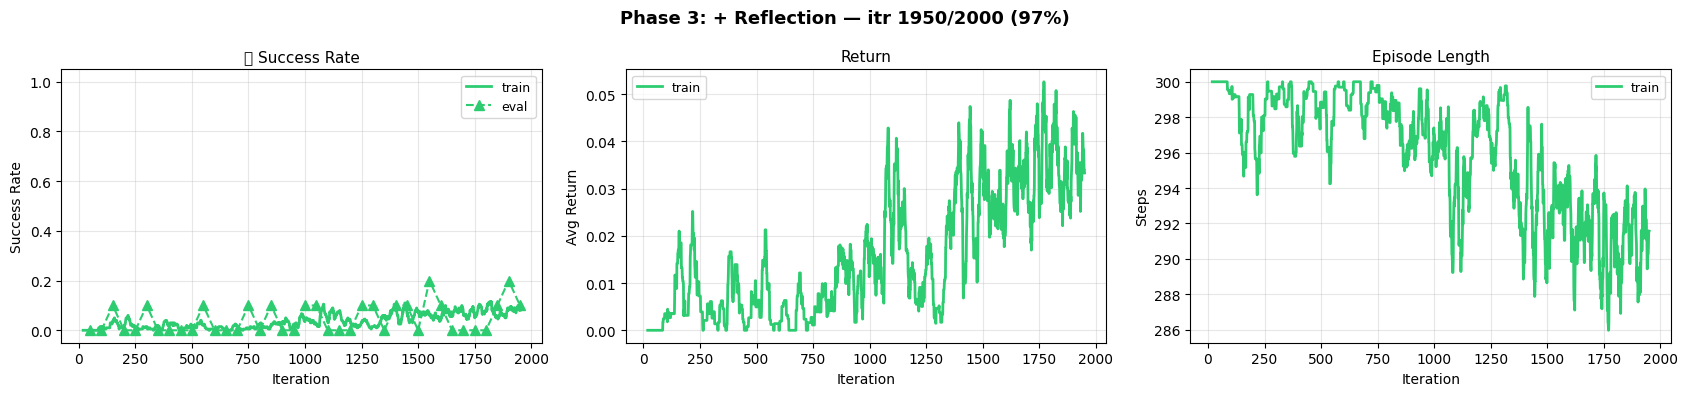

[TeacherPolicy] Plan lifetime reached (80 steps) — allowing natural replan: 'Agent sees <nothing>, holds <key>.'
[TeacherPolicy] Plan lifetime reached (80 steps) — allowing natural replan: 'Agent sees <nothing>, holds <nothing>.'
[TeacherPolicy] Intervention #69604 — reason: failed_interaction | obs: 'Agent sees <nothing>, holds <nothing>.'
[Planner] Cache invalidated for obs 'Agent sees <nothing>, holds <nothing>.' after 5 failures, confidence=0.00
new obs: Agent sees <nothing>, holds <nothing>.
[Qwen] Raw response: explore, go to <key>, pick up <key>
[Qwen] Inference succeeded — plan: go to <key>, pick up <key>
Agent sees <door>, holds <key>.:(['go to <door>, open <door>', 'explore'], [0.85, 0.15])
Agent sees <key>, holds <nothing>.:(['go to <key>, pick up <key>', 'explore'], [0.85, 0.15])
Agent sees <door>, holds <nothing>.:(['explore, pick up <key>', 'explore'], [0.85, 0.15])
Agent sees <key>, <door>, holds <nothing>.:(['go to <key>, pick up <key>', 'explore'], [0.85, 0.15])
Agent 

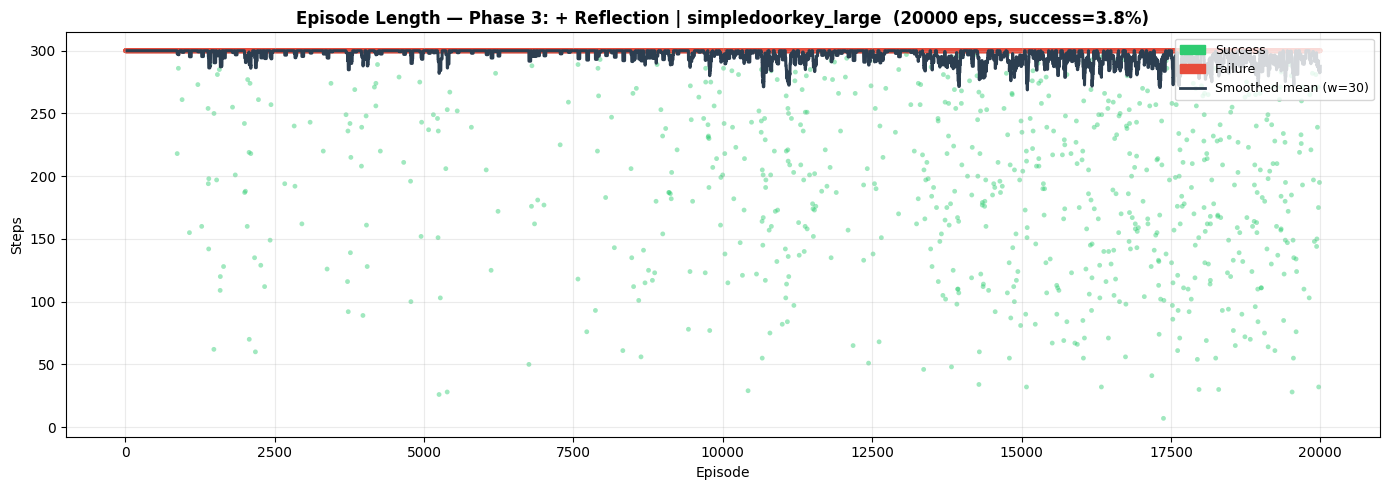

Saved: /kaggle/working/results/plots/env_metrics_reflection_simpledoorkey_large.png


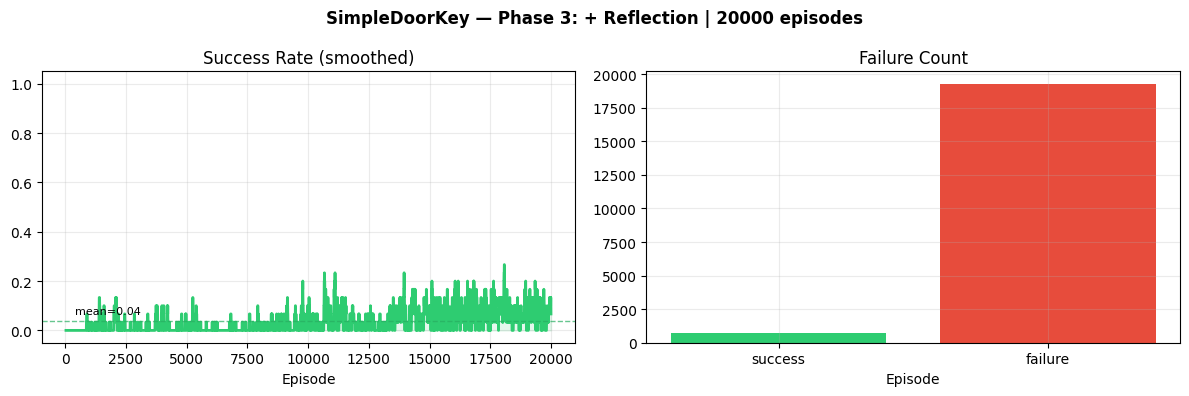


Rendering 2 evaluation episodes...
Building game for rendering: simpledoorkey_large / reflection
[Runner] Phase 'reflection': ONLINE planning — QwenLLM
[INFO]: resetting the task: simpledoorkey_large
Logging to log/ppo/simpledoorkey_large/checkpoints/phase3_reflection
use MLP......
[Game] TrajectoryLogger active → log/ppo/simpledoorkey_large/checkpoints/phase3_reflection/trajectory/
[Runner] Online LLM wired into planner.
[QwenReflector] Ollama ✅  model 'qwen2.5:3b' found.
[Game] Reflection memory wired into planner.
[Runner] Reflection system wired (reflector backend=ollama, model=qwen2.5:3b).
[LLM-MODE] phase='reflection' | planner=ONLINE (Ollama LLM) | reflector=ollama


RuntimeError: Expected all tensors to be on the same device, but got weight is on cuda:0, different from other tensors on cpu (when checking argument in method wrapper_CUDA___slow_conv2d_forward)

In [9]:
# ── Cell 8: Run single experiment ─────────────────────────────────────
if not RUN_RESEARCH_PIPELINE:
    print(f'Running: {EXPERIMENT}  backend={QWEN_BACKEND}  device={DEVICE}  task={TASK}')
    print(f'Config: {PHASE_CONFIGS.get(EXPERIMENT, {})}')
    print()

    cfg = build_experiment_config(EXPERIMENT, phase_configs=PHASE_CONFIGS)
    print(cfg.summary())

    game = build_game(
        cfg, task=TASK, device=DEVICE, seed=SEED,
        qwen_llm=_qwen_llm if cfg.use_planner and _qwen_llm else None,
    )

    _n_itr = cfg.total_iterations

    def _live_cb(history, itr):
        plot_history(history, label=EXPERIMENT, phase=EXPERIMENT,
                     itr=itr, n_itr=_n_itr, save=SAVE_PLOTS)

    history = run_phase(cfg, game=game, verbose=True,
                        plot_every=PLOT_EVERY, progress_callback=_live_cb)
    game = history.pop('_game', game)

    eval_metrics = evaluate_phase(game, cfg, n_episodes=EVAL_EPISODES)
    save_eval_results(cfg, eval_metrics)
    all_results[EXPERIMENT] = {'history': history, 'eval': eval_metrics}

    print(f'\n✅ Done: {EXPERIMENT}')
    print(f'   Success rate : {eval_metrics["success_rate"]:.3f}')
    print(f'   Avg return   : {eval_metrics["avg_reward"]:.3f}')
    print(f'   Avg ep len   : {eval_metrics["avg_episode_length"]:.1f}')
    print(f'   Teacher upper: {eval_metrics["teacher_success_rate"]:.3f}')

    # ── Progressive summary.csv save ──────────────────────────────────
    _sum_path = aggregate_results(results_dir=os.path.join(OUTPUT_DIR, 'results'))
    if _sum_path:
        print(f'   Summary CSV  : {_sum_path}')

    # ── Final env-specific charts from metrics.csv ─────────────────────
    print(f'\nGenerating final charts for {TASK} / {EXPERIMENT}...')
    plot_final_charts_from_csv(EXPERIMENT, task=TASK, save=SAVE_PLOTS)

    # Show a few evaluation episodes after training
    print('\nRendering 2 evaluation episodes...')
    render_episode_inline(cfg, max_steps=300, fps=10, n_episodes=2, use_teacher=False)
else:
    print('RUN_RESEARCH_PIPELINE=True → run Cell 9 for the full pipeline.')

In [ ]:
# ── Cell 9: Run full research pipeline ────────────────────────────────
if RUN_RESEARCH_PIPELINE:
    print(f'Starting 3-phase pipeline | backend={QWEN_BACKEND} | device={DEVICE} | task={TASK}')

    def _pipe_cb(history, itr):
        _ph = history.get('_phase', 'full')
        plot_history(history, phase=_ph, itr=itr,
                     n_itr=PHASE_CONFIGS.get(_ph, {}).get('total_iterations', 200),
                     save=SAVE_PLOTS)

    pipeline_results = run_research_pipeline(
        task=TASK, device=DEVICE, seed=SEED,
        qwen_llm=_qwen_llm if _qwen_llm else None,
        phase_configs=PHASE_CONFIGS, phases=['ppo_only', 'planner', 'reflection'], verbose=True,
        # Reflector: Ollama primary, offline backup (auto-detected). No DashScope.
        eval_episodes=EVAL_EPISODES, progress_callback=_pipe_cb,
    )
    for _k, _v in pipeline_results.items():
        if not _k.startswith('_'): all_results[_k] = _v

    # ── Progressive summary.csv + final charts after all phases ───────
    _sum_path = aggregate_results(results_dir=os.path.join(OUTPUT_DIR, 'results'))
    if _sum_path:
        print(f'Summary CSV: {_sum_path}')

    print(f'\nGenerating final charts for all phases | task={TASK}...')
    for _ph in ['ppo_only', 'planner', 'reflection']:
        if _ph in all_results:
            print(f'\n── {PHASE_LABELS.get(_ph, _ph)} ──')
            plot_final_charts_from_csv(_ph, task=TASK, save=SAVE_PLOTS)

    print('\n✅ Pipeline complete.')
else:
    print('RUN_RESEARCH_PIPELINE=False → running single experiment (Cell 8).')

In [ ]:
# ── Post-Training Analysis: charts from saved metrics.csv ─────────────────────
# Run this cell ANY TIME — after training completes OR if training was interrupted.
# Reads per-episode metrics.csv written by TrajectoryLogger during training.
# Shows ep length scatter (green=success, red=lava/failure, orange=wrong-key),
# env-specific failure rates, and failure type breakdown.
# All charts saved to results/plots/ as PNG.
import pandas as pd

print(f'Post-training analysis  |  task={TASK}')
print(f'Output dir: {OUTPUT_DIR}')
print()

_phases_to_plot = (['ppo_only', 'planner', 'reflection']
                   if RUN_RESEARCH_PIPELINE else [EXPERIMENT])

_found_any = False
for _ph in _phases_to_plot:
    _csv = _find_metrics_csv(_ph, TASK)
    if _csv and os.path.exists(_csv):
        _found_any = True
        _df = pd.read_csv(_csv)
        print(f'Phase: {PHASE_LABELS.get(_ph, _ph)}')
        print(f'  CSV      : {_csv}')
        print(f'  Episodes : {len(_df)}', end='')
        if 'success' in _df.columns:
            print(f'  |  Success: {_df["success"].mean():.1%}', end='')
        if 'steps' in _df.columns:
            print(f'  |  Avg steps: {_df["steps"].mean():.1f}', end='')
        if TASK.lower() == 'lavadoorkey' and 'lava_collision' in _df.columns:
            print(f'  |  Lava: {_df["lava_collision"].mean():.1%}', end='')
        if TASK.lower() == 'coloreddoorkey' and 'wrong_key_for_door' in _df.columns:
            print(f'  |  WrongKey: {_df["wrong_key_for_door"].mean():.1%}', end='')
        print()
        plot_episode_length_colored(_csv, _ph, task=TASK, save=SAVE_PLOTS)
        plot_env_specific_charts(_csv, _ph, task=TASK, save=SAVE_PLOTS)
        print()
    else:
        print(f'  [{_ph}] No metrics.csv found — phase not run yet.')

if not _found_any:
    print('No metrics.csv found for any phase. Run Cell 8 or 9 first.')
    print('Tip: metrics.csv is written per-episode during training, so even a')
    print('     partially completed run will have data here.')

# ── Ablation comparison (if multiple phases completed) ────────────────────────
if len(all_results) > 1:
    print('\nAblation comparison (all completed phases):')
    plot_ablation_comparison(all_results, save=SAVE_PLOTS)
    print_comparison_table(all_results)

In [ ]:
# ── Cell 10: Learning curves ───────────────────────────────────────────
if all_results:
    for _metric, _title in [
        ('success_rate',       'Success Rate — All Phases'),
        ('average_reward',     'Average Return — All Phases'),
        ('teacher_agreement',  'Teacher Agreement — All Phases'),
        ('interventions',      'Intervention Count — All Phases'),
    ]:
        plot_learning_curves(all_results, _metric, _title, save=SAVE_PLOTS)
else:
    print('No results yet. Run Cell 8 or Cell 9 first.')

In [ ]:
# ── Cell 11: Ablation comparison ──────────────────────────────────────
if all_results:
    plot_ablation_comparison(all_results, save=SAVE_PLOTS)
    print_comparison_table(all_results)
else:
    print('No results yet.')

In [ ]:
# ── Cell 12: Summary CSV ──────────────────────────────────────────────
summary_path = aggregate_results(results_dir=os.path.join(OUTPUT_DIR, 'results'))
if summary_path:
    import pandas as pd
    df = pd.read_csv(summary_path)
    print(df.to_string(index=False))
    if IS_KAGGLE:
        print(f'\nSummary saved to Kaggle output: {summary_path}')
else:
    print('No results found yet.')

In [ ]:
# ── Cell: KS / entropy / teacher-agreement curves — ALL phases ────────
# Plots KS loss magnitude, KS decay schedule (ks_coef), entropy, and
# teacher-agreement growth for every phase; saves PNG + prints a summary.
# Works after Cell 8 (single) or Cell 9 (pipeline).
import numpy as _np, os as _os
import matplotlib.pyplot as _plt
_PANELS = [('ks_loss','KS Loss Magnitude'), ('kickstarting_coef','KS Coef (decay schedule)'),
           ('entropy','Policy Entropy'), ('teacher_agreement','Teacher Agreement')]
_phases = [p for p in PHASE_ORDER if p in all_results]
if not _phases:
    print('No results yet - run Cell 8 (single) or Cell 9 (pipeline) first.')
else:
    _fig, _axes = _plt.subplots(1, 4, figsize=(22, 4))
    for _ax, (_key, _title) in zip(_axes, _PANELS):
        for _p in _phases:
            _h = all_results[_p].get('history', {})
            _itrs = _h.get('itr', [])
            _vals = [(_np.nan if v is None else v) for v in _h.get(_key, [])]
            if len(_vals) and not all(_np.isnan(_vals)):
                _ax.plot(_itrs, _vals, lw=2, color=PHASE_COLORS.get(_p, '#888'),
                         label=PHASE_LABELS.get(_p, _p))
        _ax.set_title(_title, fontsize=11); _ax.set_xlabel('Iteration')
        _ax.grid(alpha=0.3); _ax.legend(fontsize=8)
    _plt.suptitle('KS / Entropy / Teacher-Agreement - all phases', fontweight='bold')
    _plt.tight_layout()
    _fp = _os.path.join(OUTPUT_DIR, 'results', 'plots', 'ks_entropy_agreement.png')
    _os.makedirs(_os.path.dirname(_fp), exist_ok=True)
    _plt.savefig(_fp, dpi=100, bbox_inches='tight'); _plt.show()
    print('Saved ->', _fp)
    print()
    print(f"{'phase':<12}{'ks_loss(0->last)':<20}{'ks_coef(0->last)':<20}{'ta(0->last)':<18}{'ent_coef':<10}")
    for _p in _phases:
        _h = all_results[_p]['history']
        def _fl(k):
            _v = [x for x in _h.get(k, []) if x is not None]
            return f'{_v[0]:.3f}->{_v[-1]:.3f}' if _v else 'n/a'
        _ec = _h.get('entropy_coef', [0]); _ec = _ec[0] if _ec else 0
        print(f"{_p:<12}{_fl('ks_loss'):<20}{_fl('kickstarting_coef'):<20}{_fl('teacher_agreement'):<18}{_ec:<10}")


In [ ]:
# ── Cell: Teacher-signal + Pickup pipeline diagnostics ────────────────
# Verifies the teacher supervision signal is correct/useful and classifies the
# bottleneck: A) planner plans  B) plan->action conversion  C) PPO imitation  D) healthy.
# Logs the same evidence you reviewed (obs | plan | teacher_probs | argmax | ppo)
# and SAVES it to results/diagnostics.txt (included in the downloadable zip).
from diagnostics import run_all_diagnostics

# Reuse the trained game only if it actually has a planner (planner/reflection
# phases) so metric (4b) reflects the LEARNED policy; otherwise build a fresh
# planner game so the teacher-signal test is still meaningful for ppo_only runs.
_use_existing = ('game' in globals() and game is not None
                 and getattr(getattr(game, 'exp_config', None), 'use_planner', False))
_diag_game = game if _use_existing else None
_ = run_all_diagnostics(
    game=_diag_game,
    task=TASK, device=DEVICE, seed=SEED,
    qwen_llm=_qwen_llm,                # teacher uses the real (online/offline) planner backend
    out_path=os.path.join(OUTPUT_DIR, 'results', 'diagnostics.txt'),
)


In [ ]:
# ── Cell: Package ALL results into a downloadable zip ─────────────────
# Bundles every phase's history.json, metrics.csv, eval_metrics.json,
# llm_stats.json (planner_calls / cache_hits / cache_misses / online_success /
# reflections / retrievals), plots/, summary.csv and llm_mode.log.
import shutil, os, json as _json

_results_dir = os.path.join(OUTPUT_DIR, 'results')
_zip_base    = os.path.join(OUTPUT_DIR, f'llm4teach_results_{TASK}')
_zip_path    = shutil.make_archive(_zip_base, 'zip', _results_dir)
_size_mb     = os.path.getsize(_zip_path) / 1e6
print(f'Results zipped -> {_zip_path}  ({_size_mb:.2f} MB)')

print('')
print('Per-phase planner / cache / reflection counters:')
for _ph in sorted(os.listdir(_results_dir)):
    _ls = os.path.join(_results_dir, _ph, 'llm_stats.json')
    if os.path.exists(_ls):
        _d = _json.load(open(_ls))
        _p = _d.get('planner', {}); _m = _d.get('memory', {})
        print(f"  {_ph:<12} calls={_p.get('planner_calls','?')} "
              f"hits={_p.get('cache_hits','?')} miss={_p.get('cache_misses','?')} "
              f"online={_p.get('online_success','?')} "
              f"refl_added={_m.get('total_added','-')} retr={_m.get('total_retrievals','-')}")

# One-click download link (Kaggle / Jupyter)
try:
    from IPython.display import FileLink, display
    display(FileLink(_zip_path if IS_KAGGLE else os.path.relpath(_zip_path, OUTPUT_DIR)))
except Exception:
    pass
if IS_KAGGLE:
    print('On Kaggle: zip is in /kaggle/working and in the notebook Output tab for download.')


In [ ]:
# ── Cell: Reflection + Cache Checkpoint Diagnostics ──────────────────
# Run after training. Checks 3 things:
#   1. Reflection utilization (was memory actually used?)
#   2. Cache behavior (did threshold=5 cause more invalidations?)
#   3. Cluster distribution (no longer SUCCESS=everything?)
# Plus retrieval ranking verification (are retrieved memories relevant?).

import json, os

_stats_path  = os.path.join(OUTPUT_DIR, 'results', 'reflection', 'llm_stats.json')
_planner_path = os.path.join(OUTPUT_DIR, 'results', 'planner', 'llm_stats.json')

def _load(path):
    if os.path.exists(path):
        with open(path) as f: return json.load(f)
    return {}

ref_stats    = _load(_stats_path)
plan_stats   = _load(_planner_path)

# ── 1. REFLECTION UTILIZATION ─────────────────────────────────────────
print("=" * 60)
print("CHECKPOINT 1: REFLECTION UTILIZATION")
print("=" * 60)
refl = ref_stats.get("reflector", {})
mem  = ref_stats.get("memory", {})
pln  = ref_stats.get("planner", {})
print(f"  reflections_generated : {refl.get('generated', 0)}")
print(f"  reflections_validated : {refl.get('validated', 0)}")
print(f"  memory.total_added    : {mem.get('total_added', 0)}")
print(f"  memory_retrievals     : {mem.get('total_retrievals', 0)}")
print(f"  prompt_injections     : {pln.get('prompt_injections', 0)}")
print()
_inj = pln.get("prompt_injections", 0)
if _inj <= 29:
    print("  ⚠️  prompt_injections <= 29 (prev run baseline) — reflection still dormant")
elif _inj > 100:
    print(f"  ✅ prompt_injections={_inj} — reflection is reaching the LLM")
else:
    print(f"  ↑  prompt_injections improved ({_inj} > 29) — partial improvement")

# ── 2. CACHE BEHAVIOR ─────────────────────────────────────────────────
print()
print("=" * 60)
print("CHECKPOINT 2: CACHE BEHAVIOR (threshold 5 vs old 15)")
print("=" * 60)
for label, stats in [("reflection phase", pln), ("planner phase", plan_stats.get("planner", {}))]:
    total    = stats.get("planner_calls", 0)
    hits     = stats.get("cache_hits", 0)
    misses   = stats.get("cache_misses", 0)
    inv      = stats.get("cache_invalidations", 0)
    llm_ok   = stats.get("online_success", 0)
    hit_rate = hits / total if total else 0
    print(f"  [{label}]")
    print(f"    planner_calls      : {total}")
    print(f"    cache_hits         : {hits}  ({hit_rate:.2%})")
    print(f"    cache_misses       : {misses}")
    print(f"    cache_invalidations: {inv}  (prev=15, want > prev)")
    print(f"    llm_calls (online) : {llm_ok}")
    if hit_rate > 0.9999:
        print(f"    ⚠️  cache_hit_rate {hit_rate:.4%} — LLM still barely queried")
    elif hit_rate > 0.999:
        print(f"    ↑  cache_hit_rate {hit_rate:.3%} — slightly more LLM calls vs prev 99.99%")
    else:
        print(f"    ✅ cache_hit_rate {hit_rate:.2%} — good LLM utilization")
    print()

# ── 3. CLUSTER DISTRIBUTION ───────────────────────────────────────────
print("=" * 60)
print("CHECKPOINT 3: REFLECTION CLUSTER DISTRIBUTION")
print("=" * 60)
clusters = mem.get("cluster_distribution", {})
total_entries = mem.get("total_added", 0)
if not clusters:
    print("  (no memory data found)")
else:
    for cluster in ["KEY_FIRST", "DIRECT_NAVIGATION", "EXPLORE_FRONTIER",
                    "PICKUP_ALIGNMENT", "PLAN_PERSISTENCE", "SUCCESS", "GENERAL"]:
        cnt = clusters.get(cluster, 0)
        pct = 100 * cnt / max(total_entries, 1)
        bar = "#" * int(pct / 2)
        flag = "  ← RED FLAG" if cluster == "SUCCESS" and pct > 80 else ""
        flag = "  ✅" if cluster != "SUCCESS" and cnt > 0 else flag
        print(f"    {cluster:<20}: {cnt:4d} ({pct:5.1f}%) {bar}{flag}")
    if clusters.get("SUCCESS", 0) == total_entries and total_entries > 0:
        print()
        print("  ❌ ALL entries are SUCCESS — cluster fix did not work")
    elif clusters.get("SUCCESS", 0) < total_entries * 0.5:
        print()
        print("  ✅ Cluster diversity restored — fix worked")

# ── 4. RETRIEVAL RANKING SPOT-CHECK ───────────────────────────────────
print()
print("=" * 60)
print("CHECKPOINT 4: RETRIEVAL RANKING SPOT-CHECK")
print("=" * 60)
try:
    from memory.memory_buffer import ReflectionMemory
    _mem_path = os.path.join(OUTPUT_DIR, "log", "ppo", TASK,
                             "checkpoints", "phase3_reflection", "reflection_memory.json")
    if os.path.exists(_mem_path):
        _mem = ReflectionMemory(maxlen=20, top_k=5)
        _mem.load(_mem_path)
        _mem.verbose_retrieval = True
        print(f"  Memory has {len(_mem)} entries. Spot-checking 4 query clusters:")
        for qc in ["KEY_FIRST", "EXPLORE_FRONTIER", "DIRECT_NAVIGATION", "SUCCESS"]:
            print(f"  --- Query cluster: {qc} ---")
            _ = _mem.get_context(current_cluster=qc, max_entries=3)
            for r in _mem._last_retrieval:
                match_icon = "✅" if r["cluster_match"] else "❌"
                print(f"    {match_icon} [{r['retrieved_cluster']:<20}] succ={r['success_rate']:.0%} ",
                      r["reflection"][:60])
            print()
    else:
        print(f"  reflection_memory.json not found at {_mem_path}")
        print("  (memory is not persisted to disk by default — add game.save_reflection_memory() after training)")
except Exception as e:
    print(f"  Could not load memory for spot-check: {e}")


In [ ]:
# # ── Cell 13: Render saved episodes (post-training replay) ─────────────
# # Watch the trained PPO agent vs teacher policy side-by-side.

# if all_results:
#     _phase_to_show = EXPERIMENT if EXPERIMENT in all_results else list(all_results.keys())[-1]
#     _cfg_show = build_experiment_config(_phase_to_show, phase_configs=PHASE_CONFIGS)

#     print(f'Showing PPO agent ({_phase_to_show}) — 2 episodes')
#     render_episode_inline(_cfg_show, max_steps=200, fps=8, n_episodes=2, use_teacher=False)

#     print(f'Showing teacher policy — 1 episode')
#     render_episode_inline(_cfg_show, max_steps=200, fps=8, n_episodes=1, use_teacher=True)
# else:
#     print('Run Cell 8 or 9 first to train a model.')

---
## 📋 Kaggle Quick-Start Checklist

1. **Upload this repo** as a Kaggle Dataset (zip the project folder)
2. **Add it as input** — `/kaggle/input/llm4teach/`
3. **Set `REPO`** in Cell 2 if auto-detection fails:
   ```python
   REPO = '/kaggle/input/llm4teach/LLM4Teach-main'
   ```
4. **LLM options on Kaggle:**
   - `QWEN_BACKEND = 'offline'` — always works, no server needed.
   - `QWEN_BACKEND = 'ollama'` — **Cell 4 now AUTOMATICALLY installs Ollama,
     starts the server, and pulls the model in-kernel**, so the planner AND
     reflector run online. Requirements: **Settings → Internet: ON** (and a GPU
     is recommended for speed). If any step fails it auto-falls back to offline.
     The active mode is printed in Cell 4 and recorded in `results/llm_mode.log`.
5. **Results** are saved to `/kaggle/working/results/` (Kaggle output)

## 📋 Local Quick-Start

```bash
# Start local LLM (optional)
ollama pull qwen2.5:3b && ollama serve

# Start live training visualizer
python viz/run_viz.py    # then open http://localhost:7860

# Or run notebook directly
jupyter notebook Research_Ablation_Notebook.ipynb
```

## Component flags reference
| Flag | Phase 1 | Phase 2 | Phase 3 | Phase 4 | Phase 5 |
|------|:-------:|:-------:|:-------:|:-------:|:-------:|
| `use_teacher_policy` | ❌ | ✅ | ✅ | ✅ | ✅ |
| `use_planner` | ❌ | ✅ | ✅ | ✅ | ✅ |
| `use_kickstarting` | ❌ | ✅ | ✅ | ✅ | ✅ |
| `use_reflection` | ❌ | ❌ | ✅ | ✅ | ✅ |
| `use_episode_memory` | ❌ | ❌ | ✅ | ✅ | ✅ |
| `use_mid_episode_replanning` | ❌ | ❌ | ❌ | ✅ | ✅ |

In [ ]:
# ── Zip ALL output folders for download ───────────────────────────────
import os, zipfile, time
from IPython.display import FileLink, display

# Where outputs live (works on Kaggle and locally)
_ROOT     = OUTPUT_DIR if 'OUTPUT_DIR' in globals() else os.getcwd()
_FOLDERS  = ['results', 'checkpoints', 'log']          # folders to include
_stamp    = time.strftime('%Y%m%d_%H%M%S')
_zip_path = os.path.join(_ROOT, f'llm4teach_ALL_{_stamp}.zip')

_n, _bytes = 0, 0
with zipfile.ZipFile(_zip_path, 'w', zipfile.ZIP_DEFLATED) as zf:
    for folder in _FOLDERS:
        src = os.path.join(_ROOT, folder)
        if not os.path.isdir(src):
            print(f'  skip (missing): {folder}')
            continue
        for dirpath, _, files in os.walk(src):
            for fn in files:
                fp  = os.path.join(dirpath, fn)
                arc = os.path.relpath(fp, _ROOT)          # keep folder structure
                zf.write(fp, arc)
                _n += 1; _bytes += os.path.getsize(fp)
        print(f'  added {folder}/')

print(f'\nZipped {_n} files ({_bytes/1e6:.1f} MB) -> {_zip_path}')
try:
    display(FileLink(_zip_path if 'IS_KAGGLE' in globals() and IS_KAGGLE
                     else os.path.relpath(_zip_path, _ROOT)))
except Exception:
    pass
if 'IS_KAGGLE' in globals() and IS_KAGGLE:
    print('On Kaggle: also appears in the right-sidebar Output tab.')